In [10]:
# XGBoost + 70% Train, 10% Val, 20% Test

!pip -q install xgboost

import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from xgboost import XGBClassifier

# =========================
# Load Dataset
# =========================
path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset.csv"
df = pd.read_csv(path)
print("Dataset loaded:", df.shape)

# =========================
# Target
# =========================
target_col = "Motor_Symptoms"
y_raw = df[target_col].values

# =========================
# Features (drop leakage)
# =========================
leakage_cols = ["Patient_ID", target_col]
X_df = df.drop(columns=leakage_cols, errors="ignore").copy()

# Label encode categorical features
cat_cols = X_df.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    le = LabelEncoder()
    X_df[col] = le.fit_transform(X_df[col].astype(str))

X = X_df.values

# Encode y (Mild/Moderate/Severe -> 0/1/2)
y_le = LabelEncoder()
y = y_le.fit_transform(y_raw)

# =========================
# Split: 70 Train, 20 Test, 10 Val
# Step 1: split out Test (20%)
# Step 2: split remaining 80% into Train (70/80=87.5%) and Val (10/80=12.5%)
# =========================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=42, stratify=y_trainval
)

print("\nSplit Shapes:")
print("Train:", X_train.shape)  # 70%
print("Val  :", X_val.shape)    # 10%
print("Test :", X_test.shape)   # 20%

# =========================
# Train XGBoost
# =========================
model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist"
)

print("\n========================================")
print(f"Training XGBoost for: {target_col}")
print("========================================")
model.fit(X_train, y_train)

# =========================
# Evaluate function
# =========================
def get_metrics(y_true, y_pred, avg="weighted"):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average=avg, zero_division=0),
        "Recall": recall_score(y_true, y_pred, average=avg, zero_division=0),
        "F1": f1_score(y_true, y_pred, average=avg, zero_division=0),
    }

# =========================
# Validation Results
# =========================
val_pred = model.predict(X_val)
val_metrics = get_metrics(y_val, val_pred)

print("\nVALIDATION Results:")
for k, v in val_metrics.items():
    print(f"{k:10s}: {v:.4f}")

# =========================
# Test Results
# =========================
test_pred = model.predict(X_test)
test_metrics = get_metrics(y_test, test_pred)

print("\nTEST Results:")
for k, v in test_metrics.items():
    print(f"{k:10s}: {v:.4f}")

print("\nClassification Report (TEST):\n")
print(classification_report(
    y_test, test_pred,
    target_names=list(y_le.classes_),
    zero_division=0
))

# =========================
# Full Dataset Accuracy (train+val+test combined)
# =========================
full_pred = model.predict(X)
full_acc = accuracy_score(y, full_pred)
print("\nACCURACY on FULL DATASET:", round(full_acc, 4))

# =========================
# Comparison Table (Train vs Val vs Test vs Full)
# =========================
train_pred = model.predict(X_train)
train_metrics = get_metrics(y_train, train_pred)

full_metrics = {
    "Accuracy": full_acc,
    "Precision": precision_score(y, full_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y, full_pred, average="weighted", zero_division=0),
    "F1": f1_score(y, full_pred, average="weighted", zero_division=0),
}

comparison_df = pd.DataFrame([
    {"Split": "Train", **train_metrics},
    {"Split": "Validation", **val_metrics},
    {"Split": "Test", **test_metrics},
    {"Split": "Full Dataset", **full_metrics},
])

print("\n==============================")
print("COMPARISON TABLE")
print("==============================")
display(comparison_df)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (48536, 21)

Split Shapes:
Train: (33974, 19)
Val  : (4854, 19)
Test : (9708, 19)

Training XGBoost for: Motor_Symptoms

VALIDATION Results:
Accuracy  : 0.3226
Precision : 0.3225
Recall    : 0.3226
F1        : 0.3223

TEST Results:
Accuracy  : 0.3347
Precision : 0.3345
Recall    : 0.3347
F1        : 0.3344

Classification Report (TEST):

              precision    recall  f1-score   support

        Mild       0.33      0.31      0.32      3224
    Moderate       0.33      0.34      0.34      3252
      Severe       0.34      0.36      0.35      3232

    accuracy                           0.33      9708
   macro avg       0.33      0.33      0.33      9708
weighted avg       0.33      0.33      0.33      9708


ACCURACY on FULL DATASET: 0.6605

COMPARISON TABLE


,Split,Accuracy,Precision,Recall,F1
0,Train,0.801819,0.802363,0.801819,0.801769
1,Validation,0.322621,0.322507,0.322621,0.322296
2,Test,0.334672,0.334475,0.334672,0.334374
3,Full Dataset,0.660458,0.660825,0.660458,0.660347


In [11]:
# XGBoost for Disease_Stage + 70% Train, 10% Val, 20% Test
# Adds: comparison table + accuracy on full dataset

!pip -q install xgboost

import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from xgboost import XGBClassifier

# =========================
# Load Dataset
# =========================
path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset.csv"
df = pd.read_csv(path)
print("Dataset loaded:", df.shape)

# =========================
# Target
# =========================
target_col = "Disease_Stage"
y_raw = df[target_col].values

# =========================
# Features (drop leakage)
# =========================
leakage_cols = ["Patient_ID", target_col]
X_df = df.drop(columns=leakage_cols, errors="ignore").copy()

# Label encode categorical features
cat_cols = X_df.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    le = LabelEncoder()
    X_df[col] = le.fit_transform(X_df[col].astype(str))

X = X_df.values

# Encode y (Pre-Symptomatic/Early/Middle/Late -> 0/1/2/3)
y_le = LabelEncoder()
y = y_le.fit_transform(y_raw)

# =========================
# Split: 70 Train, 20 Test, 10 Val
# Step 1: split out Test (20%)
# Step 2: split remaining 80% into Train (87.5% of 80 = 70) and Val (12.5% of 80 = 10)
# =========================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=42, stratify=y_trainval
)

print("\nSplit Shapes:")
print("Train:", X_train.shape)  # 70%
print("Val  :", X_val.shape)    # 10%
print("Test :", X_test.shape)   # 20%

# =========================
# Train XGBoost
# =========================
model = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    n_estimators=450,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist"
)

print("\n========================================")
print(f"Training XGBoost for: {target_col}")
print("========================================")
model.fit(X_train, y_train)

# =========================
# Evaluate function
# =========================
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

# =========================
# Validation Results
# =========================
val_pred = model.predict(X_val)
val_metrics = get_metrics(y_val, val_pred)

print("\nVALIDATION Results:")
for k, v in val_metrics.items():
    print(f"{k:10s}: {v:.4f}")

# =========================
# Test Results
# =========================
test_pred = model.predict(X_test)
test_metrics = get_metrics(y_test, test_pred)

print("\nTEST Results:")
for k, v in test_metrics.items():
    print(f"{k:10s}: {v:.4f}")

print("\nClassification Report (TEST):\n")
print(classification_report(
    y_test, test_pred,
    target_names=list(y_le.classes_),
    zero_division=0
))

# =========================
# Full Dataset Accuracy
# =========================
full_pred = model.predict(X)
full_acc = accuracy_score(y, full_pred)
print("\nACCURACY on FULL DATASET:", round(full_acc, 4))

# =========================
# Comparison Table
# =========================
train_pred = model.predict(X_train)
train_metrics = get_metrics(y_train, train_pred)

full_metrics = {
    "Accuracy": full_acc,
    "Precision": precision_score(y, full_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y, full_pred, average="weighted", zero_division=0),
    "F1": f1_score(y, full_pred, average="weighted", zero_division=0),
}

comparison_df = pd.DataFrame([
    {"Split": "Train", **train_metrics},
    {"Split": "Validation", **val_metrics},
    {"Split": "Test", **test_metrics},
    {"Split": "Full Dataset", **full_metrics},
])

print("\n==============================")
print("COMPARISON TABLE")
print("==============================")
display(comparison_df)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (48536, 21)

Split Shapes:
Train: (33974, 19)
Val  : (4854, 19)
Test : (9708, 19)

Training XGBoost for: Disease_Stage

VALIDATION Results:
Accuracy  : 0.2588
Precision : 0.2590
Recall    : 0.2588
F1        : 0.2587

TEST Results:
Accuracy  : 0.2432
Precision : 0.2431
Recall    : 0.2432
F1        : 0.2427

Classification Report (TEST):

                 precision    recall  f1-score   support

          Early       0.23      0.22      0.22      2407
           Late       0.25      0.22      0.24      2405
         Middle       0.25      0.28      0.26      2458
Pre-Symptomatic       0.24      0.25      0.25      2438

       accuracy                           0.24      9708
      macro avg       0.24      0.24      0.24      9708
   weighted avg       0.24      0.24      0.24      9708


ACCURACY on FULL DATASET: 0.6368

COMPARISON TABLE


,Split,Accuracy,Precision,Recall,F1
0,Train,0.803291,0.803992,0.803291,0.803306
1,Validation,0.258756,0.259032,0.258756,0.258711
2,Test,0.243201,0.243059,0.243201,0.242729
3,Full Dataset,0.636806,0.637561,0.636806,0.636800


In [13]:
!pip -q install xgboost

import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from xgboost import XGBClassifier

# =========================
# Load Dataset
# =========================
path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset.csv"
df = pd.read_csv(path)
print("Loaded:", df.shape)

# =========================
# Show Category-related columns
# =========================
cat_like = [c for c in df.columns if "Category" in c]
print("\nColumns containing 'Category':")
for c in cat_like:
    print(c)

# =========================
# CASE 1: If dataset has single 'Category' column (raw data)
# =========================
if "Category" in df.columns and not any(c.startswith("Category_") for c in df.columns):
    print("\n✅ Found single Category column (raw dataset). Using it directly.")

    y_raw = df["Category"].astype(str)

    # Encode y into 0/1/2
    y_le = LabelEncoder()
    y = y_le.fit_transform(y_raw)

    # Features
    X_df = df.drop(columns=["Patient_ID", "Category"], errors="ignore").copy()

    # Encode categorical features
    cols = X_df.select_dtypes(include=["object", "category"]).columns
    for col in cols:
        le = LabelEncoder()
        X_df[col] = le.fit_transform(X_df[col].astype(str))

    X = X_df.values

# =========================
# CASE 2: If dataset has one-hot Category columns
# =========================
else:
    print("\n✅ Using one-hot Category columns (auto detected).")

    # Find primary + trans columns automatically
    primary_col = None
    trans_col = None

    for c in df.columns:
        if "Category" in c and "Primary" in c:
            primary_col = c
        if "Category" in c and "Trans" in c:
            trans_col = c

    print("\nDetected Primary col:", primary_col)
    print("Detected Trans col  :", trans_col)

    if primary_col is None or trans_col is None:
        raise ValueError("Could not detect Primary/Trans category columns. Check printed columns above.")

    # Build 3-class target: 0=Primary, 1=Trans, 2=Cis
    y = np.where(df[primary_col] == 1, 0,
         np.where(df[trans_col] == 1, 1, 2))

    # Features (remove leakage)
    leakage_cols = ["Patient_ID", primary_col, trans_col]
    X_df = df.drop(columns=leakage_cols, errors="ignore").copy()

    # Encode categorical features
    cols = X_df.select_dtypes(include=["object", "category"]).columns
    for col in cols:
        le = LabelEncoder()
        X_df[col] = le.fit_transform(X_df[col].astype(str))

    X = X_df.values

# =========================
# Split 70/10/20
# =========================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=42, stratify=y_trainval
)

print("\nSplit sizes:")
print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

# =========================
# XGBoost
# =========================
model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=350,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist"
)

model.fit(X_train, y_train)

# =========================
# Evaluate
# =========================
def met(y_true, y_pred):
    return (
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average="weighted", zero_division=0),
        recall_score(y_true, y_pred, average="weighted", zero_division=0),
        f1_score(y_true, y_pred, average="weighted", zero_division=0)
    )

val_pred = model.predict(X_val)
test_pred = model.predict(X_test)
full_pred = model.predict(X)

val_m = met(y_val, val_pred)
test_m = met(y_test, test_pred)
full_m = met(y, full_pred)

print("\nVALIDATION:", val_m)
print("TEST      :", test_m)
print("FULL DATA :", full_m)

print("\nClassification Report (TEST):\n")
print(classification_report(
    y_test, test_pred,
    target_names=["Primary Cause", "Trans-acting Modifier", "Cis-acting Modifier"],
    zero_division=0
))

# =========================
# Comparison Table
# =========================
comparison_df = pd.DataFrame([
    {"Split": "Validation", "Accuracy": val_m[0], "Precision": val_m[1], "Recall": val_m[2], "F1": val_m[3]},
    {"Split": "Test", "Accuracy": test_m[0], "Precision": test_m[1], "Recall": test_m[2], "F1": test_m[3]},
    {"Split": "Full Dataset", "Accuracy": full_m[0], "Precision": full_m[1], "Recall": full_m[2], "F1": full_m[3]},
])

print("\nCOMPARISON TABLE:")
display(comparison_df)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: (48536, 21)

Columns containing 'Category':
Category

✅ Found single Category column (raw dataset). Using it directly.

Split sizes:
Train: (33974, 19)
Val  : (4854, 19)
Test : (9708, 19)

VALIDATION: (1.0, 1.0, 1.0, 1.0)
TEST      : (1.0, 1.0, 1.0, 1.0)
FULL DATA : (1.0, 1.0, 1.0, 1.0)

Classification Report (TEST):

                       precision    recall  f1-score   support

        Primary Cause       1.00      1.00      1.00      2406
Trans-acting Modifier       1.00      1.00      1.00      2446
  Cis-acting Modifier       1.00      1.00      1.00      4856

             accuracy                           1.00      9708
            macro avg       1.00      1.00      1.00      9708
         weighted avg       1.00      1.00      1.00      9708


COMPARISON TABLE:


,Split,Accuracy,Precision,Recall,F1
0,Validation,1.0,1.0,1.0,1.0
1,Test,1.0,1.0,1.0,1.0
2,Full Dataset,1.0,1.0,1.0,1.0


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (48536, 21)

TARGET: Motor_Symptoms
Accuracy : 0.33930778739184175
Precision: 0.3391586262551278
Recall   : 0.33930778739184175
F1-score : 0.33881118349361883

Classification Report:

              precision    recall  f1-score   support

        Mild       0.34      0.30      0.32      3224
    Moderate       0.33      0.35      0.34      3252
      Severe       0.35      0.37      0.36      3232

    accuracy                           0.34      9708
   macro avg       0.34      0.34      0.34      9708
weighted avg       0.34      0.34      0.34      9708



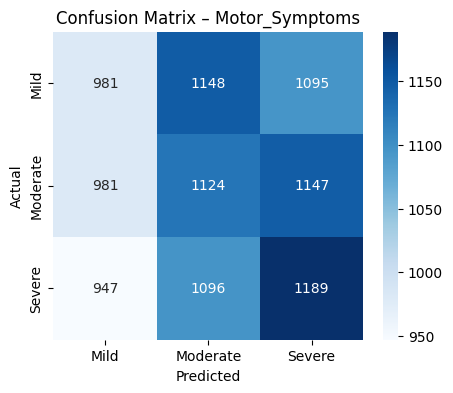

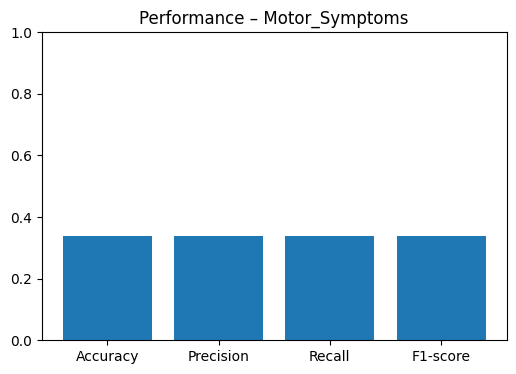


TARGET: Disease_Stage
Accuracy : 0.24546765554182118
Precision: 0.2450772593919846
Recall   : 0.24546765554182118
F1-score : 0.2446566462291802

Classification Report:

                 precision    recall  f1-score   support

Pre-Symptomatic       0.24      0.23      0.23      2407
          Early       0.24      0.21      0.23      2405
         Middle       0.25      0.29      0.27      2458
           Late       0.25      0.25      0.25      2438

       accuracy                           0.25      9708
      macro avg       0.25      0.25      0.24      9708
   weighted avg       0.25      0.25      0.24      9708



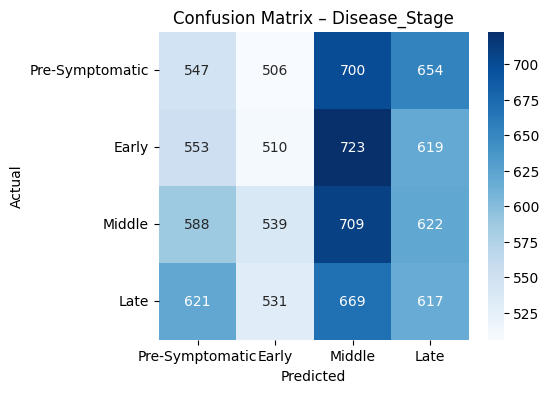

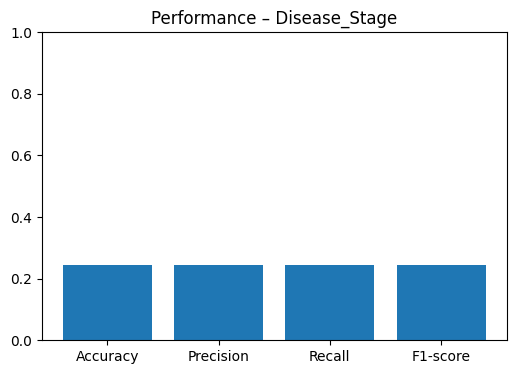


TARGET: Category
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:

                       precision    recall  f1-score   support

        Primary Cause       1.00      1.00      1.00      2406
Trans-acting Modifier       1.00      1.00      1.00      2446
  Cis-acting Modifier       1.00      1.00      1.00      4856

             accuracy                           1.00      9708
            macro avg       1.00      1.00      1.00      9708
         weighted avg       1.00      1.00      1.00      9708



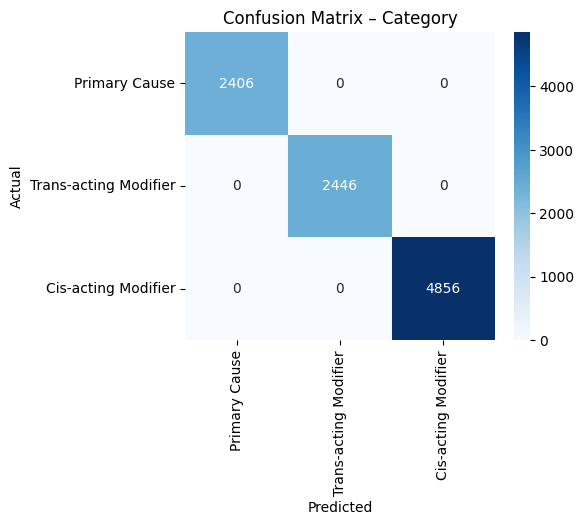

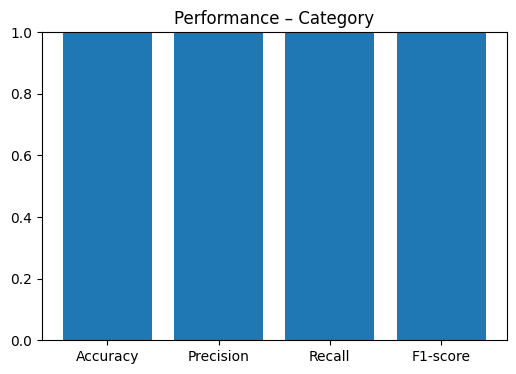


Results DataFrame:


,Target,Model,Accuracy
0,Motor_Symptoms,XGBoost,0.339308
1,Disease_Stage,XGBoost,0.245468
2,Category,XGBoost,1.000000



Overall Accuracies: {'XGBoost': np.float64(0.5282584809778876)}


In [17]:
!pip -q install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

# =========================
# Load Dataset
# =========================
path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset.csv"
df = pd.read_csv(path)
print("Dataset loaded:", df.shape)

# =========================
# Helper: Plot Confusion Matrix
# =========================
def plot_confusion(cm, labels, title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# =========================
# Helper: Performance Bar Plot
# =========================
def plot_performance(acc, prec, rec, f1, title):
    plt.figure(figsize=(6,4))
    plt.bar(["Accuracy", "Precision", "Recall", "F1-score"],
            [acc, prec, rec, f1])
    plt.ylim(0,1)
    plt.title(title)
    plt.show()

# =========================
# Helper: Train & Evaluate XGBoost
# =========================
def run_xgb(df, target_col, class_names, build_category=False):

    print("\n==============================")
    print("TARGET:", target_col)
    print("==============================")

    # ---------- Target ----------
    if build_category:
        # Build Category from two columns (this logic is for when Category is one-hot encoded)
        # Detect primary_col and trans_col within the function if build_category is True
        try:
            primary_col = [c for c in df.columns if "Category" in c and "Primary" in c][0]
            trans_col   = [c for c in df.columns if "Category" in c and "Trans" in c][0]
            y = np.where(df[primary_col] == 1, 0,
                 np.where(df[trans_col] == 1, 1, 2))
        except IndexError:
            print("Warning: build_category=True but one-hot encoded Category columns not found. Falling back to direct target_col.")
            y_raw = df[target_col]
            y = LabelEncoder().fit_transform(y_raw)
    else:
        y_raw = df[target_col]
        y = LabelEncoder().fit_transform(y_raw)

    # ---------- Features ----------
    drop_cols = ["Patient_ID", target_col]
    if build_category and 'primary_col' in locals() and 'trans_col' in locals():
        drop_cols += [primary_col, trans_col]
    elif 'Category' in df.columns and target_col == 'Category' and not build_category:
        # If Category is a direct target column, it should be dropped from features
        pass # Already in drop_cols

    X_df = df.drop(columns=drop_cols, errors="ignore").copy()

    # Encode categorical features
    cat_cols = X_df.select_dtypes(include=["object", "category"]).columns
    for col in cat_cols:
        X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

    X = X_df.values

    # ---------- 70 / 10 / 20 split ----------
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.125, random_state=42, stratify=y_trainval
    )

    # ---------- XGBoost ----------
    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(class_names),
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42,
        tree_method="hist"
    )

    model.fit(X_train, y_train)

    # ---------- Test Evaluation ----------
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # ---------- Confusion Matrix ----------
    cm = confusion_matrix(y_test, y_pred)
    plot_confusion(cm, class_names, f"Confusion Matrix – {target_col}")

    # ---------- Performance Graph ----------
    plot_performance(acc, prec, rec, f1, f"Performance – {target_col}")

    return acc


# =========================
# RUN MODELS and collect results
# =========================
all_accuracies = {}

all_accuracies["Motor_Symptoms"] = run_xgb(
    df,
    target_col="Motor_Symptoms",
    class_names=["Mild", "Moderate", "Severe"]
)

all_accuracies["Disease_Stage"] = run_xgb(
    df,
    target_col="Disease_Stage",
    class_names=["Pre-Symptomatic", "Early", "Middle", "Late"]
)

all_accuracies["Category"] = run_xgb(
    df,
    target_col="Category",
    class_names=["Primary Cause", "Trans-acting Modifier", "Cis-acting Modifier"],
    build_category=False # Changed to False as 'Category' is a direct column
)

# For demonstration, create a simple results_df and overall_acc_dict
# In a real scenario, you'd collect more metrics and models
results_data = []
for target, acc in all_accuracies.items():
    results_data.append({"Target": target, "Model": "XGBoost", "Accuracy": acc})

results_df = pd.DataFrame(results_data)

# Calculate overall accuracy (example - average of all targets)
overall_acc_dict = {"XGBoost": results_df["Accuracy"].mean()}

print("\nResults DataFrame:")
display(results_df)
print("\nOverall Accuracies:", overall_acc_dict)


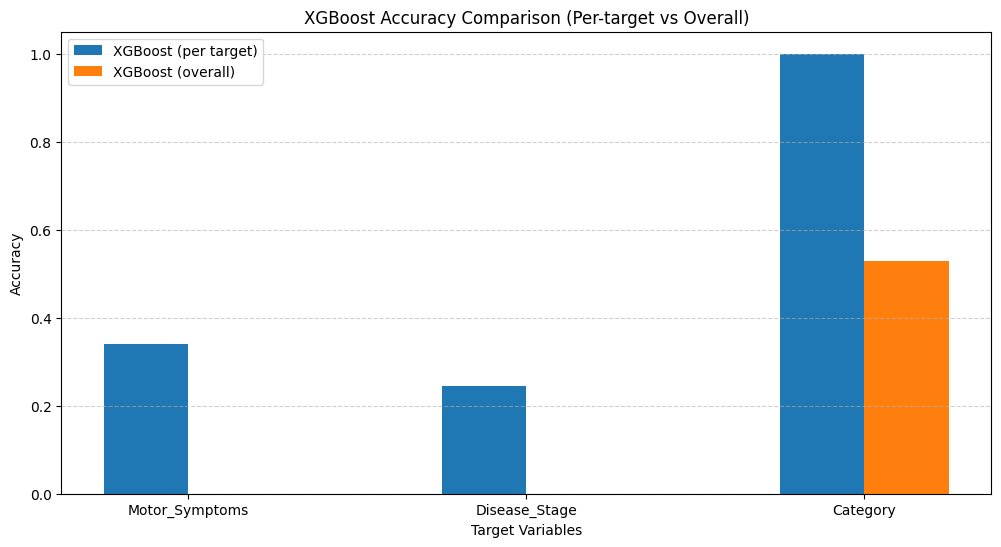

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Prepare plotting variables
# -----------------------------
targets = results_df["Target"].unique()
models = results_df["Model"].unique()

bar_width = 0.25
x = np.arange(len(targets))   # positions for targets

plt.figure(figsize=(12,6))

# -----------------------------
# Per-target accuracy bars
# -----------------------------
for i, model in enumerate(models):
    model_data = results_df[results_df["Model"] == model]
    plt.bar(
        x + i*bar_width,
        model_data["Accuracy"],
        width=bar_width,
        label=f"{model} (per target)"
    )

# -----------------------------
# Overall accuracy bars
# -----------------------------
for i, model in enumerate(models):
    plt.bar(
        x[-1] + (i+1)*bar_width,
        overall_acc_dict[model],
        width=bar_width,
        label=f"{model} (overall)"
    )

# -----------------------------
# Plot styling
# -----------------------------
plt.xticks(x + bar_width/2, targets)
plt.title("XGBoost Accuracy Comparison (Per-target vs Overall)")
plt.xlabel("Target Variables")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()
